In [20]:
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Imports done")

Imports done


In [21]:
# ── Load labeled puzzles ─────────────────────────────────────────────
with open("../data/puzzles_labeled.json", "r") as f:
    puzzles = json.load(f)

print(f"Loaded {len(puzzles)} labeled puzzles")

# ── Fix words list to come from groups (ensures consistency) ─────────
for puzzle in puzzles:
    words_from_groups = []
    for group in puzzle["groups"]:
        words_from_groups.extend(group["members"])
    puzzle["words"] = words_from_groups

# ── Remove April Fools emoji puzzle ──────────────────────────────────
puzzles = [p for p in puzzles if p["puzzle_id"] != 295]
print(f"Puzzles after removing emoji puzzle: {len(puzzles)}")

# ── Load MPNet and compute embeddings ────────────────────────────────
print("Loading MPNet model...")
model = SentenceTransformer("all-mpnet-base-v2")
print("Model loaded")

print("Computing embeddings...")
for puzzle in puzzles:
    embeddings = model.encode(puzzle["words"], show_progress_bar=False)
    puzzle["embeddings"] = embeddings

print(f"Embeddings computed for {len(puzzles)} puzzles")

Loaded 227 labeled puzzles
Puzzles after removing emoji puzzle: 226
Loading MPNet model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
Computing embeddings...
Embeddings computed for 226 puzzles


In [22]:
# ── Color mapping ────────────────────────────────────────────────────
COLORS = {0: "yellow", 1: "green", 2: "blue", 3: "purple"}
COLOR_HEX = {0: "#F9DF6D", 1: "#A0C35A", 2: "#B0C4EF", 3: "#BA81C5"}

def get_group_embeddings(puzzle):
    """Returns dict of {level: {words, embeddings}} for each group."""
    word_list = puzzle["words"]
    emb_array = np.array(puzzle["embeddings"])
    word_to_emb = {w: emb_array[i] for i, w in enumerate(word_list)}

    groups = {}
    for group in puzzle["groups"]:
        level = group["level"]
        members = group["members"]
        embs = np.array([word_to_emb[w] for w in members])
        groups[level] = {"words": members, "embeddings": embs}
    return groups

def cohesion(embeddings):
    """Mean pairwise cosine similarity within a group."""
    sims = cosine_similarity(embeddings)
    n = len(embeddings)
    total = sum(sims[i][j] for i in range(n) for j in range(i+1, n))
    return total / (n * (n - 1) / 2)

def confusability(group_embs, other_embs):
    """Mean cosine similarity between a group and all other words."""
    sims = cosine_similarity(group_embs, other_embs)
    return sims.mean()

def puzzle_metrics(puzzle):
    """Compute cohesion, confusability, and silhouette for a puzzle."""
    groups = get_group_embeddings(puzzle)
    all_embs = np.array(puzzle["embeddings"])
    all_words = puzzle["words"]

    word_to_level = {}
    for group in puzzle["groups"]:
        for w in group["members"]:
            word_to_level[w] = group["level"]
    labels = [word_to_level[w] for w in all_words]

    results = {}
    for level, data in groups.items():
        g_embs = data["embeddings"]
        other_embs = np.vstack([
            groups[l]["embeddings"] for l in groups if l != level
        ])
        results[level] = {
            "cohesion": cohesion(g_embs),
            "confusability": confusability(g_embs, other_embs)
        }

    sil = silhouette_score(all_embs, labels, metric="cosine")
    mean_coh = np.mean([r["cohesion"] for r in results.values()])
    mean_conf = np.mean([r["confusability"] for r in results.values()])

    return {
        "mean_cohesion": mean_coh,
        "mean_confusability": mean_conf,
        "silhouette": sil,
        "by_group": results
    }

print("Metric functions defined")

Metric functions defined


In [23]:
# ── Compute metrics for all puzzles ─────────────────────────────────
records = []
for puzzle in puzzles:
    metrics = puzzle_metrics(puzzle)
    records.append({
        "puzzle_id": puzzle["puzzle_id"],
        "date": puzzle["date"],
        "difficulty": puzzle["difficulty"],
        "mean_cohesion": metrics["mean_cohesion"],
        "mean_confusability": metrics["mean_confusability"],
        "silhouette": metrics["silhouette"],
        "by_group": metrics["by_group"]
    })

df = pd.DataFrame(records)

# ── Correlations table (Table 4.1) ───────────────────────────────────
corr_cols = ["difficulty", "mean_cohesion", "mean_confusability", "silhouette"]
print("Pairwise correlations:")
print(df[corr_cols].corr().round(3))

Pairwise correlations:
                    difficulty  mean_cohesion  mean_confusability  silhouette
difficulty               1.000         -0.196               0.054      -0.240
mean_cohesion           -0.196          1.000               0.346       0.823
mean_confusability       0.054          0.346               1.000      -0.206
silhouette              -0.240          0.823              -0.206       1.000


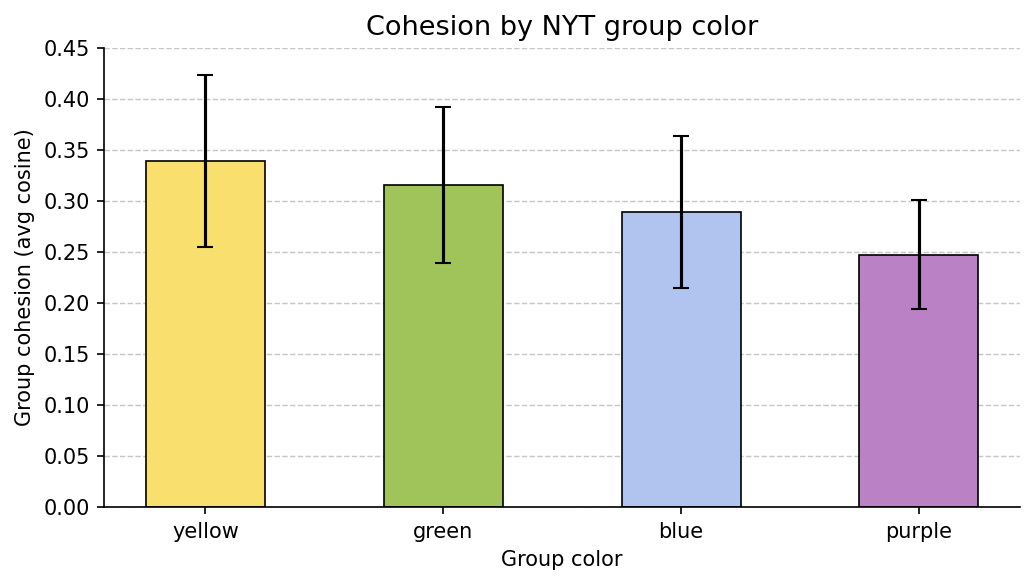

Means: {'yellow': np.float32(0.339), 'green': np.float32(0.316), 'blue': np.float32(0.289), 'purple': np.float32(0.247)}


In [25]:
# ── Figure 4.1: Mean group cohesion by color ─────────────────────────
color_cohesion = {0: [], 1: [], 2: [], 3: []}

for puzzle in puzzles:
    metrics = puzzle_metrics(puzzle)
    for level, data in metrics["by_group"].items():
        color_cohesion[level].append(data["cohesion"])

means = [np.mean(color_cohesion[l]) for l in range(4)]
stds = [np.std(color_cohesion[l]) for l in range(4)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [COLORS[l] for l in range(4)],
    means,
    yerr=stds,
    color=[COLOR_HEX[l] for l in range(4)],
    edgecolor="black",
    linewidth=0.8,
    capsize=4,
    width=0.5
)

ax.set_title("Cohesion by NYT group color", fontsize=13)
ax.set_xlabel("Group color")
ax.set_ylabel("Group cohesion (avg cosine)")
ax.set_ylim(0, 0.45)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_1_cohesion_by_color.png", dpi=150, bbox_inches="tight")
plt.show()
print("Means:", {COLORS[l]: round(means[l], 3) for l in range(4)})

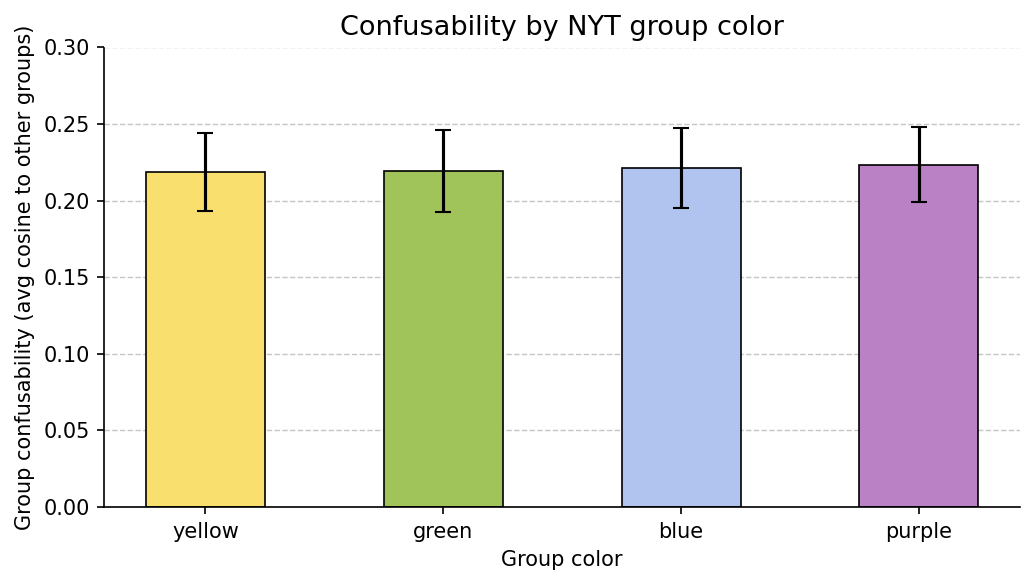

Means: {'yellow': np.float32(0.219), 'green': np.float32(0.219), 'blue': np.float32(0.221), 'purple': np.float32(0.223)}


In [26]:
# ── Figure 4.2: Mean group confusability by color ────────────────────
color_confusability = {0: [], 1: [], 2: [], 3: []}

for puzzle in puzzles:
    metrics = puzzle_metrics(puzzle)
    for level, data in metrics["by_group"].items():
        color_confusability[level].append(data["confusability"])

means_conf = [np.mean(color_confusability[l]) for l in range(4)]
stds_conf = [np.std(color_confusability[l]) for l in range(4)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [COLORS[l] for l in range(4)],
    means_conf,
    yerr=stds_conf,
    color=[COLOR_HEX[l] for l in range(4)],
    edgecolor="black",
    linewidth=0.8,
    capsize=4,
    width=0.5
)

ax.set_title("Confusability by NYT group color", fontsize=13)
ax.set_xlabel("Group color")
ax.set_ylabel("Group confusability (avg cosine to other groups)")
ax.set_ylim(0, 0.30)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_2_confusability_by_color.png", dpi=150, bbox_inches="tight")
plt.show()
print("Means:", {COLORS[l]: round(means_conf[l], 3) for l in range(4)})

In [27]:
# ── Figures 4.3, 4.4, 4.5: PCA embedding visualizations ─────────────
def plot_puzzle_pca(puzzle, title, save_path):
    all_embs = np.array(puzzle["embeddings"])
    all_words = puzzle["words"]
    
    # build color labels
    word_to_level = {}
    for group in puzzle["groups"]:
        for w in group["members"]:
            word_to_level[w] = group["level"]
    
    # PCA projection
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_embs)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for i, word in enumerate(all_words):
        level = word_to_level[word]
        ax.scatter(coords[i, 0], coords[i, 1],
                  color=COLOR_HEX[level], edgecolor="black",
                  linewidth=0.5, s=80, zorder=3)
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                   fontsize=7, ha="left", va="bottom",
                   xytext=(3, 3), textcoords="offset points")
    
    # legend
    handles = [mpatches.Patch(color=COLOR_HEX[l], label=COLORS[l]) 
               for l in range(4)]
    ax.legend(handles=handles, title="Group color", fontsize=8)
    
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# find median, easiest, hardest puzzles
df_sorted = df.sort_values("difficulty").reset_index(drop=True)
easiest = df_sorted.iloc[0]
hardest = df_sorted.iloc[-1]
median_idx = len(df_sorted) // 2
median = df_sorted.iloc[median_idx]

print(f"Easiest:  puzzle {int(easiest.puzzle_id)}, date {easiest.date}, difficulty {easiest.difficulty}")
print(f"Median:   puzzle {int(median.puzzle_id)}, date {median.date}, difficulty {median.difficulty}")
print(f"Hardest:  puzzle {int(hardest.puzzle_id)}, date {hardest.date}, difficulty {hardest.difficulty}")

Easiest:  puzzle 159, date 2023-11-17, difficulty 1.3
Median:   puzzle 262, date 2024-02-28, difficulty 3.0
Hardest:  puzzle 145, date 2023-11-03, difficulty 4.8


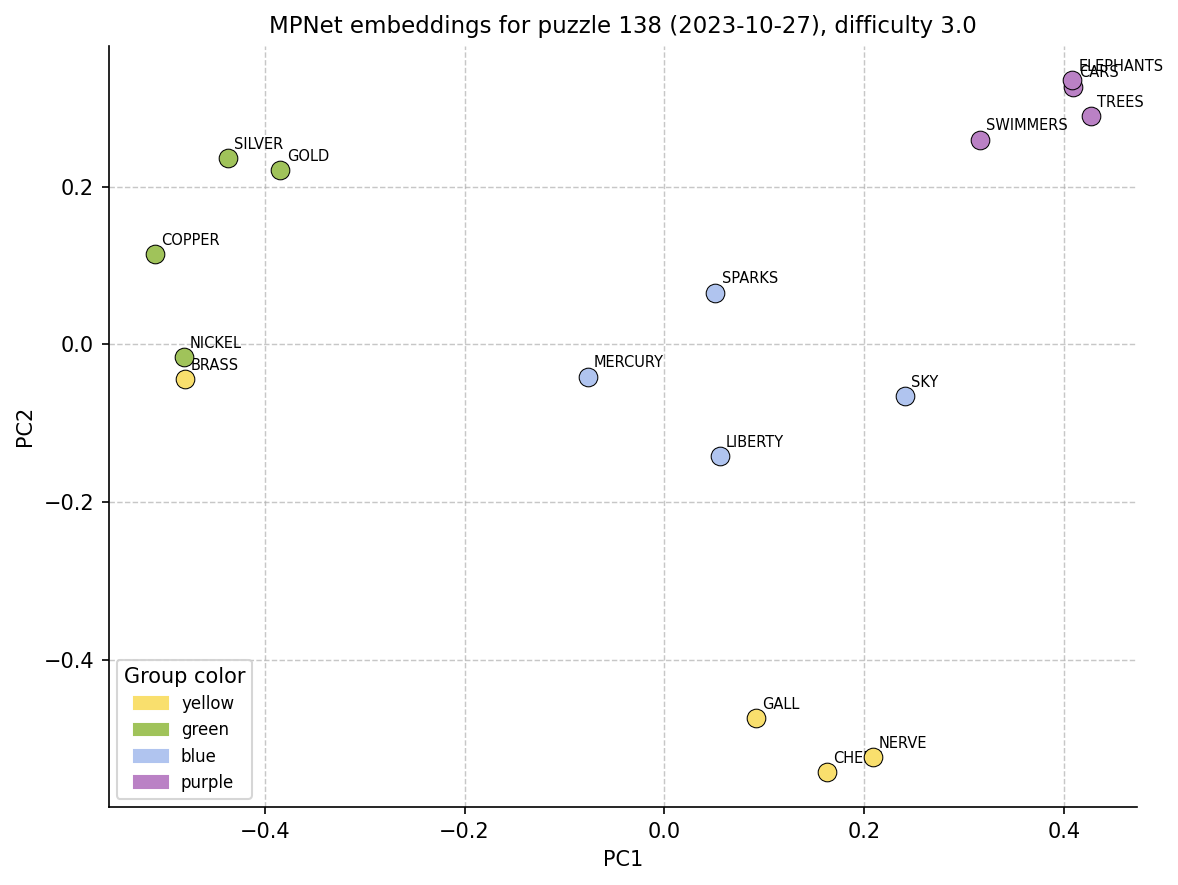

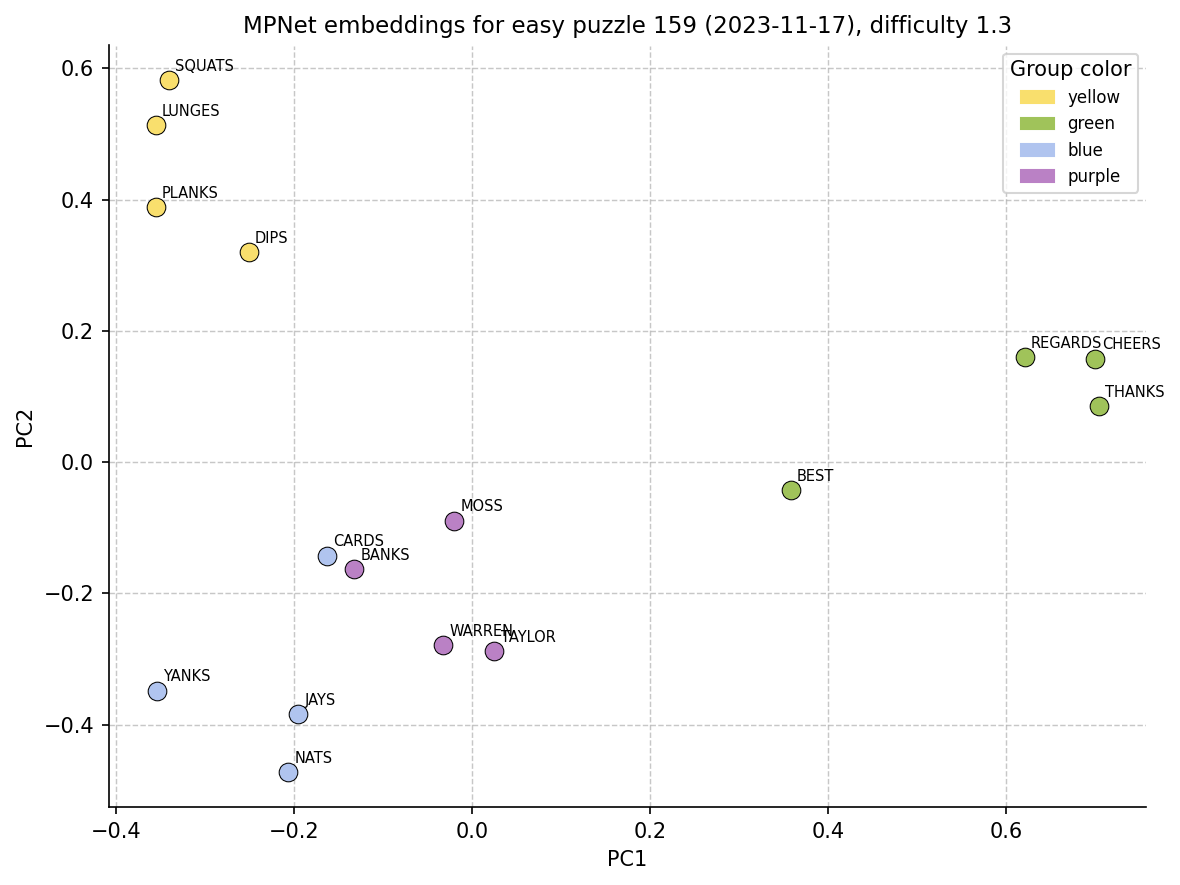

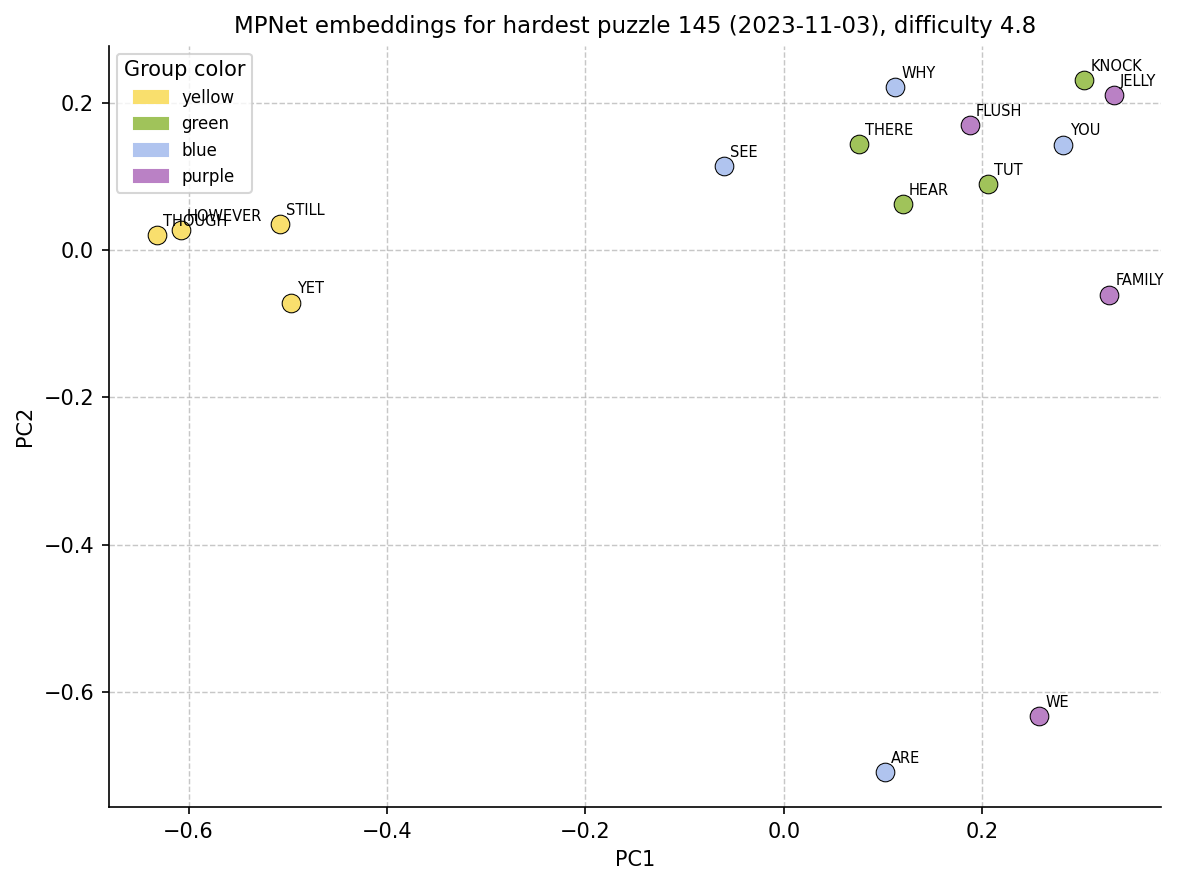

In [28]:
# ── Get puzzle objects by ID ─────────────────────────────────────────
def get_puzzle_by_id(puzzle_id):
    for p in puzzles:
        if p["puzzle_id"] == puzzle_id:
            return p
    return None

puzzle_easy   = get_puzzle_by_id(159)
puzzle_median = get_puzzle_by_id(138)
puzzle_hard   = get_puzzle_by_id(145)

# ── Figure 4.3: Median difficulty puzzle ─────────────────────────────
plot_puzzle_pca(
    puzzle_median,
    f"MPNet embeddings for puzzle 138 ({puzzle_median['date']}), difficulty {df[df['puzzle_id']==138]['difficulty'].values[0]}",
    "../results/fig4_3_pca_median.png"
)

# ── Figure 4.4: Easy puzzle ───────────────────────────────────────────
plot_puzzle_pca(
    puzzle_easy,
    f"MPNet embeddings for easy puzzle 159 ({puzzle_easy['date']}), difficulty 1.3",
    "../results/fig4_4_pca_easy.png"
)

# ── Figure 4.5: Hard puzzle ───────────────────────────────────────────
plot_puzzle_pca(
    puzzle_hard,
    f"MPNet embeddings for hardest puzzle 145 ({puzzle_hard['date']}), difficulty 4.8",
    "../results/fig4_5_pca_hard.png"
)

In [29]:
# ── Load all four embedding models ───────────────────────────────────
print("Loading models... this may take a few minutes")

models = {
    "mpnet": SentenceTransformer("all-mpnet-base-v2"),
    "bert":  SentenceTransformer("bert-base-nli-mean-tokens"),
    "minilm": SentenceTransformer("all-MiniLM-L6-v2"),
    "bge":   SentenceTransformer("BAAI/bge-small-en-v1.5"),
}

print("All models loaded")

Loading models... this may take a few minutes


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

All models loaded


In [30]:
# ── Compute separation for all models ───────────────────────────────
def compute_separation(puzzle, emb_model):
    words = puzzle["words"]
    embeddings = emb_model.encode(words, show_progress_bar=False)
    word_to_emb = {w: embeddings[i] for i, w in enumerate(words)}
    
    sep_scores = []
    for group in puzzle["groups"]:
        members = group["members"]
        g_embs = np.array([word_to_emb[w] for w in members])
        other_words = [w for w in words if w not in members]
        o_embs = np.array([word_to_emb[w] for w in other_words])
        
        coh = cohesion(g_embs)
        conf = confusability(g_embs, o_embs)
        sep_scores.append(coh - conf)
    
    return np.mean(sep_scores)

# ── Build results dataframe ──────────────────────────────────────────
model_results = []
for model_name, emb_model in models.items():
    print(f"Computing separation for {model_name}...")
    for puzzle in puzzles:
        sep = compute_separation(puzzle, emb_model)
        puzzle_id = puzzle["puzzle_id"]
        difficulty = df[df["puzzle_id"] == puzzle_id]["difficulty"].values[0]
        model_results.append({
            "model": model_name,
            "puzzle_id": puzzle_id,
            "difficulty": difficulty,
            "separation": sep
        })

model_df = pd.DataFrame(model_results)
print("Done")
print(model_df.groupby("model")["separation"].describe().round(3))

Computing separation for mpnet...
Computing separation for bert...
Computing separation for minilm...
Computing separation for bge...
Done
        count   mean    std    min    25%    50%    75%    max
model                                                         
bert    226.0  0.049  0.032 -0.010  0.024  0.044  0.066  0.163
bge     226.0  0.034  0.018 -0.004  0.021  0.033  0.046  0.083
minilm  226.0  0.059  0.033 -0.016  0.035  0.056  0.082  0.163
mpnet   226.0  0.077  0.038  0.002  0.047  0.075  0.102  0.242


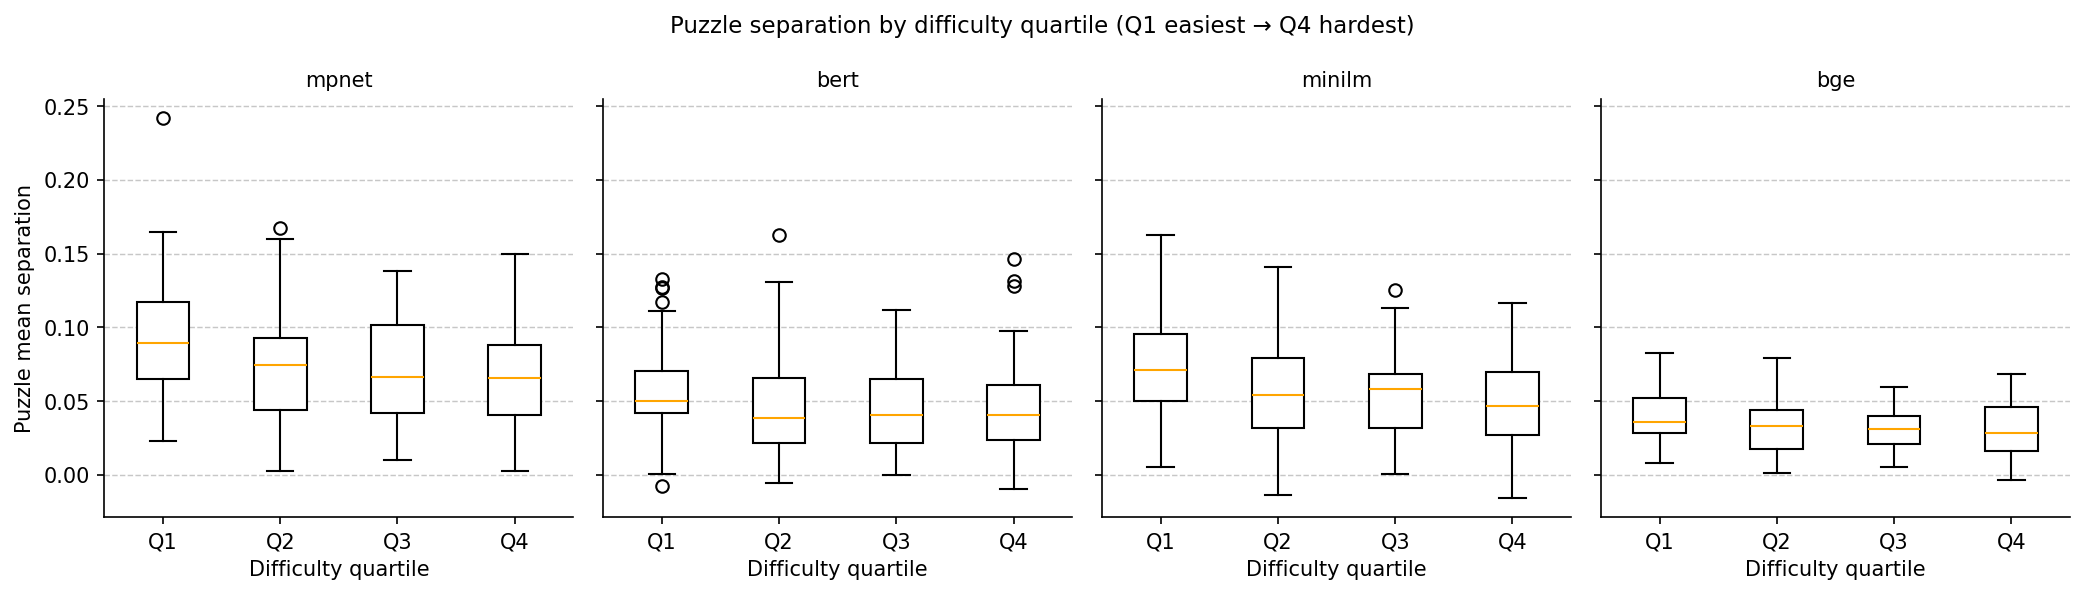

In [31]:
# ── Figure 4.6: Separation by difficulty quartile ────────────────────
model_df["quartile"] = model_df.groupby("model")["difficulty"].transform(
    lambda x: pd.qcut(x, 4, labels=["Q1", "Q2", "Q3", "Q4"])
)

model_order = ["mpnet", "bert", "minilm", "bge"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle("Puzzle separation by difficulty quartile (Q1 easiest → Q4 hardest)", fontsize=11)

for ax, model_name in zip(axes, model_order):
    mdf = model_df[model_df["model"] == model_name]
    data = [mdf[mdf["quartile"] == q]["separation"].values for q in ["Q1", "Q2", "Q3", "Q4"]]
    bp = ax.boxplot(data, labels=["Q1", "Q2", "Q3", "Q4"], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("white")
    for median in bp["medians"]:
        median.set_color("orange")
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel("Difficulty quartile")
    if ax == axes[0]:
        ax.set_ylabel("Puzzle mean separation")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_6_separation_by_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

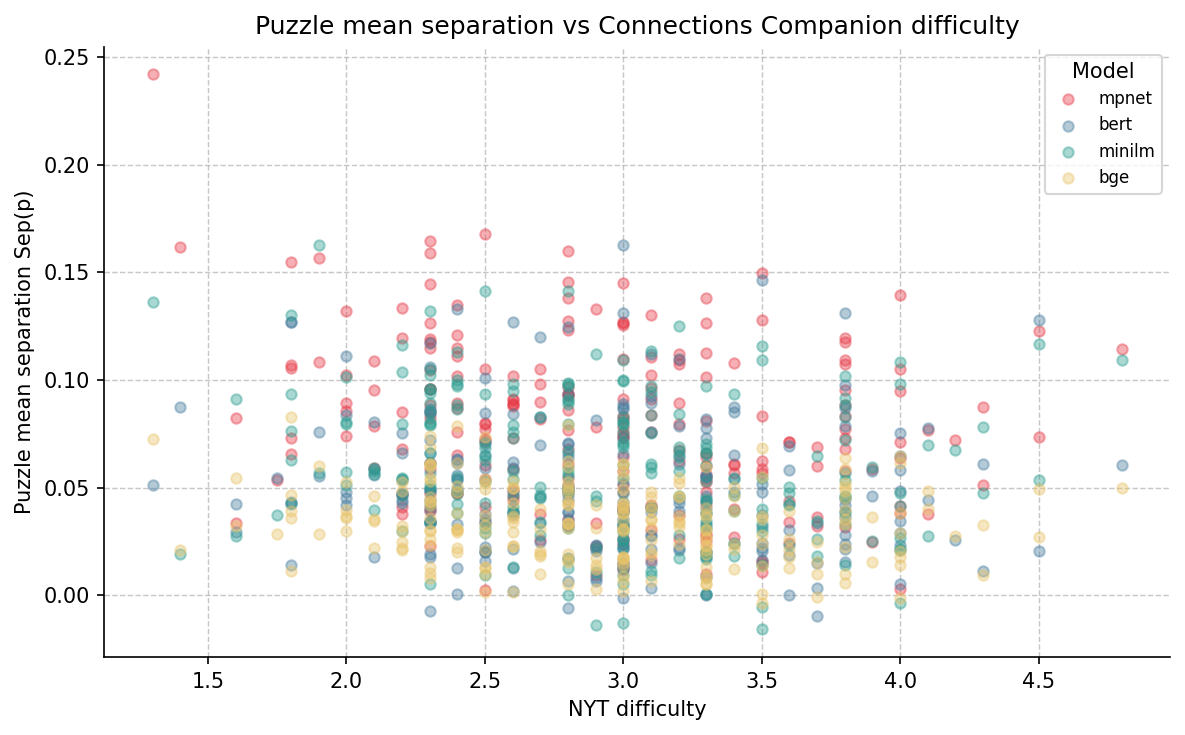

In [35]:
# ── Figure 4.7: Separation vs difficulty scatter ──────────────────────
model_colors = {
    "mpnet": "#E63946",
    "bert": "#457B9D",
    "minilm": "#2A9D8F",
    "bge": "#E9C46A"
}

fig, ax = plt.subplots(figsize=(8, 5))

for model_name in model_order:
    mdf = model_df[model_df["model"] == model_name]
    ax.scatter(
        mdf["difficulty"], mdf["separation"],
        color=model_colors[model_name],
        alpha=0.4, s=25, label=model_name
    )

ax.set_xlabel("NYT difficulty")
ax.set_ylabel("Puzzle mean separation Sep(p)")
ax.set_title("Puzzle mean separation vs Connections Companion difficulty")
ax.legend(title="Model", fontsize=8)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_7_separation_vs_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

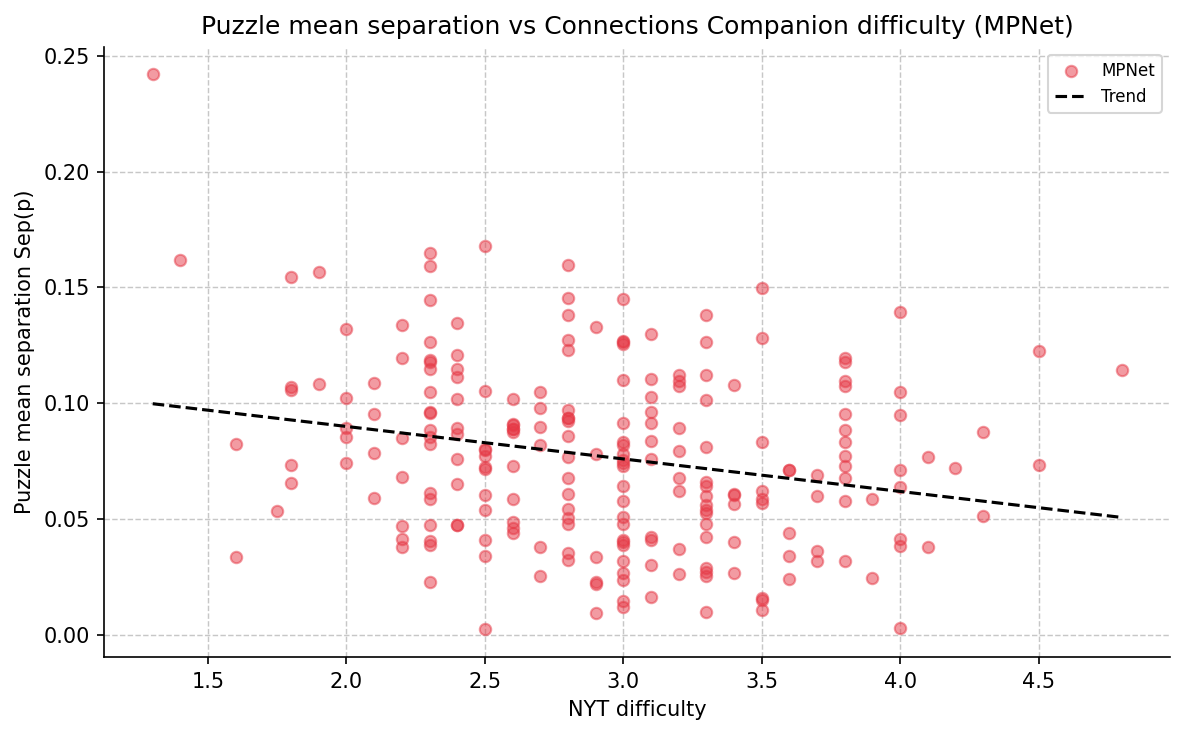

Correlation (MPNet separation vs difficulty): -0.235


In [34]:
# ── Figure 4.7: Separation vs difficulty (MPNet only) ─────────────────
from numpy.polynomial.polynomial import polyfit

mdf = model_df[model_df["model"] == "mpnet"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    mdf["difficulty"], mdf["separation"],
    color="#E63946", alpha=0.5, s=30, label="MPNet"
)

# trend line
x = mdf["difficulty"].values
y = mdf["separation"].values
coefs = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coefs, x_line),
        color="black", linewidth=1.5, linestyle="--", label="Trend")

ax.set_xlabel("NYT difficulty")
ax.set_ylabel("Puzzle mean separation Sep(p)")
ax.set_title("Puzzle mean separation vs Connections Companion difficulty (MPNet)")
ax.legend(fontsize=8)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_10_mpnet_separation_vs_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

# print correlation
print(f"Correlation (MPNet separation vs difficulty): {np.corrcoef(x, y)[0,1]:.3f}")

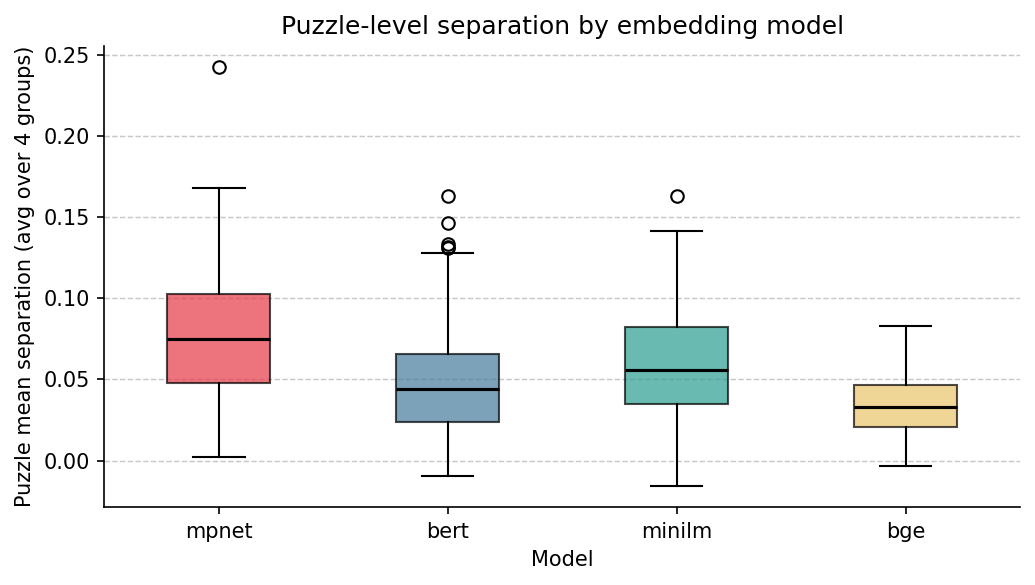

In [36]:
# ── Figure 4.8: Distribution of separation across models ─────────────
fig, ax = plt.subplots(figsize=(7, 4))

data = [model_df[model_df["model"] == m]["separation"].values for m in model_order]
bp = ax.boxplot(data, labels=model_order, patch_artist=True)

for patch, model_name in zip(bp["boxes"], model_order):
    patch.set_facecolor(model_colors[model_name])
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax.set_title("Puzzle-level separation by embedding model", fontsize=12)
ax.set_xlabel("Model")
ax.set_ylabel("Puzzle mean separation (avg over 4 groups)")
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_8_separation_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
def compute_false_groups(puzzle, delta=0.20):
    words = puzzle["words"]
    emb_array = np.array(puzzle["embeddings"])
    word_to_emb = {w: emb_array[i] for i, w in enumerate(words)}
    
    true_groups = [frozenset(g["members"]) for g in puzzle["groups"]]
    
    true_cohesions = []
    for g in puzzle["groups"]:
        embs = np.array([word_to_emb[w] for w in g["members"]])
        true_cohesions.append(cohesion(embs))
    tau = min(true_cohesions)
    
    # absolute threshold
    threshold = tau + delta
    
    strong_false = []
    for combo in combinations(words, 4):
        s = frozenset(combo)
        if s in true_groups:
            continue
        embs = np.array([word_to_emb[w] for w in combo])
        c = cohesion(embs)
        if c >= threshold:
            strong_false.append(c)
    
    n_false = len(strong_false)
    best_gap = max(strong_false) - tau if n_false > 0 else None
    
    return {"n_false": n_false, "best_gap": best_gap, "tau": tau}

print("Reverted to absolute threshold")

Reverted to absolute threshold


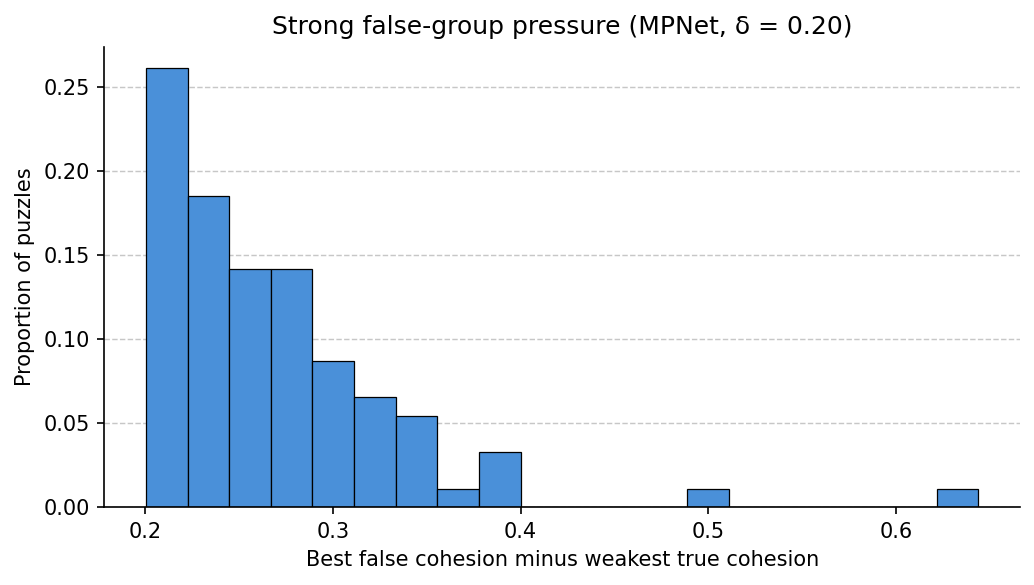

In [54]:
# ── Figure 4.9: Best-false gap distribution (proportion) ─────────────
fig, ax = plt.subplots(figsize=(7, 4))

counts, bin_edges = np.histogram(has_false["best_gap"], bins=20)
proportions = counts / len(has_false)

ax.bar(
    bin_edges[:-1], proportions,
    width=np.diff(bin_edges),
    color="#4A90D9",
    edgecolor="black",
    linewidth=0.6,
    align="edge"
)

ax.set_title("Strong false-group pressure (MPNet, δ = 0.20)", fontsize=12)
ax.set_xlabel("Best false cohesion minus weakest true cohesion", fontsize=10)
ax.set_ylabel("Proportion of puzzles", fontsize=10)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig4_9_false_group_gap.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# ── Difficulty-binned averages (replacing Table 4.1) ─────────────────
bins = [1.0, 2.0, 3.0, 4.0, 5.0]
labels = ["1-2", "2-3", "3-4", "4-5"]

df["difficulty_bin"] = pd.cut(df["difficulty"], bins=bins, labels=labels)

binned = df.groupby("difficulty_bin", observed=True).agg(
    n_puzzles=("difficulty", "count"),
    avg_difficulty=("difficulty", "mean"),
    avg_cohesion=("mean_cohesion", "mean"),
    avg_confusability=("mean_confusability", "mean"),
    avg_silhouette=("silhouette", "mean")
).round(3)

print("Average metrics by difficulty bin:")
print(binned.to_string())

Average metrics by difficulty bin:
                n_puzzles  avg_difficulty  avg_cohesion  avg_confusability  avg_silhouette
difficulty_bin                                                                            
1-2                    17           1.791         0.327              0.219           0.093
2-3                   118           2.614         0.300              0.221           0.053
3-4                    83           3.483         0.288              0.220           0.041
4-5                     8           4.350         0.302              0.223           0.056


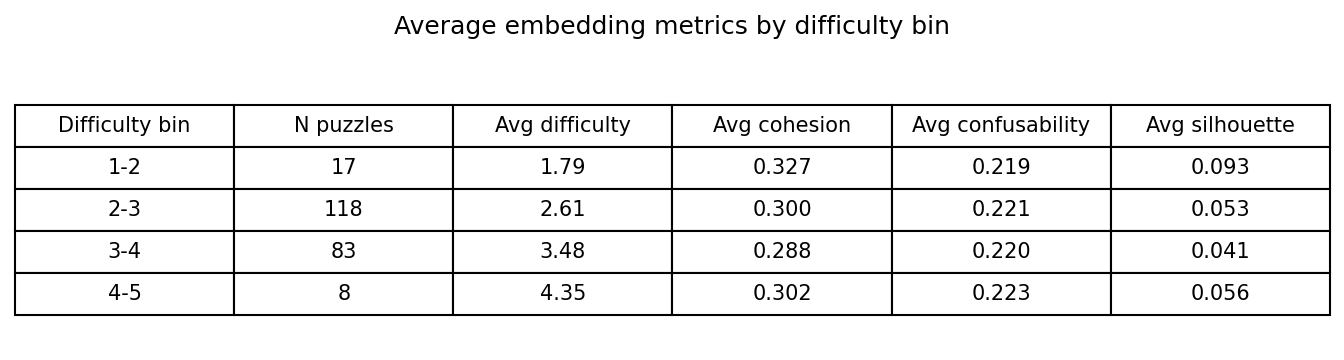

In [56]:
# ── Save binned table as a figure ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")

table_data = [
    [row.Index, int(row.n_puzzles), f"{row.avg_difficulty:.2f}",
     f"{row.avg_cohesion:.3f}", f"{row.avg_confusability:.3f}",
     f"{row.avg_silhouette:.3f}"]
    for row in binned.itertuples()
]

col_labels = ["Difficulty bin", "N puzzles", "Avg difficulty",
              "Avg cohesion", "Avg confusability", "Avg silhouette"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.title("Average embedding metrics by difficulty bin", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("../results/table4_1_difficulty_binned.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# ── Delta sensitivity analysis ────────────────────────────────────────
deltas = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

delta_records = []
for delta in deltas:
    n_with_false = 0
    gaps = []
    n_false_counts = []
    for puzzle in puzzles:
        result = compute_false_groups(puzzle, delta=delta)
        n_false_counts.append(result["n_false"])
        if result["best_gap"] is not None:
            n_with_false += 1
            gaps.append(result["best_gap"])
    
    delta_records.append({
        "delta": delta,
        "n_puzzles_with_false": n_with_false,
        "pct_puzzles_with_false": n_with_false / len(puzzles) * 100,
        "mean_n_false": np.mean(n_false_counts),
        "mean_best_gap": np.mean(gaps) if gaps else None
    })

delta_df = pd.DataFrame(delta_records)
print(delta_df.round(3).to_string())

   delta  n_puzzles_with_false  pct_puzzles_with_false  mean_n_false  mean_best_gap
0   0.05                   226                 100.000       369.779          0.199
1   0.10                   215                  95.133        92.876          0.205
2   0.15                   167                  73.894        19.088          0.226
3   0.20                    92                  40.708         4.336          0.268
4   0.25                    47                  20.796         1.712          0.312
5   0.30                    21                   9.292         0.841          0.361
6   0.35                     6                   2.655         0.168          0.451
7   0.40                     2                   0.885         0.066          0.575


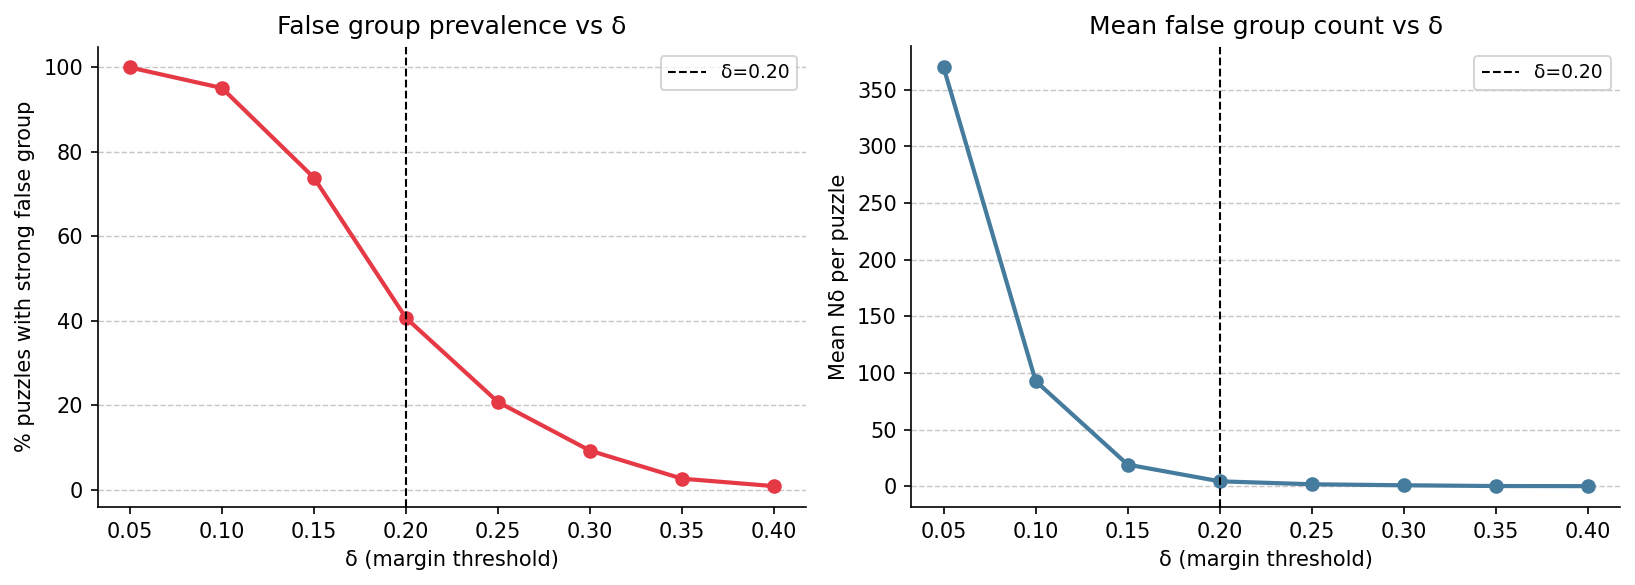

In [59]:
# ── Figure: Delta sensitivity analysis ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# left panel: % puzzles with at least one strong false group
ax1.plot(delta_df["delta"], delta_df["pct_puzzles_with_false"],
         marker="o", color="#E63946", linewidth=2)
ax1.axvline(x=0.20, color="black", linestyle="--", linewidth=1, label="δ=0.20")
ax1.set_xlabel("δ (margin threshold)")
ax1.set_ylabel("% puzzles with strong false group")
ax1.set_title("False group prevalence vs δ")
ax1.legend(fontsize=9)
ax1.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax1.set_axisbelow(True)

# right panel: mean number of strong false groups per puzzle
ax2.plot(delta_df["delta"], delta_df["mean_n_false"],
         marker="o", color="#457B9D", linewidth=2)
ax2.axvline(x=0.20, color="black", linestyle="--", linewidth=1, label="δ=0.20")
ax2.set_xlabel("δ (margin threshold)")
ax2.set_ylabel("Mean Nδ per puzzle")
ax2.set_title("Mean false group count vs δ")
ax2.legend(fontsize=9)
ax2.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_delta_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Overlap signature analysis ────────────────────────────────────────
def overlap_signature(s, true_groups):
    """Returns sorted overlap counts between s and each true group."""
    overlaps = [len(s & frozenset(g["members"])) for g in true_groups]
    return tuple(sorted(overlaps, reverse=True))

def categorize_signature(sig):
    if sig == (3, 1, 0, 0): return "near-miss"
    elif sig == (2, 2, 0, 0): return "two-and-two"
    elif sig == (2, 1, 1, 0): return "mix-decoy"
    else: return "other"

# compute signatures for all strong false groups at delta=0.20
sig_records = []
for puzzle in puzzles:
    words = puzzle["words"]
    emb_array = np.array(puzzle["embeddings"])
    word_to_emb = {w: emb_array[i] for i, w in enumerate(words)}
    true_groups = puzzle["groups"]
    true_group_sets = [frozenset(g["members"]) for g in true_groups]
    
    true_cohesions = []
    for g in true_groups:
        embs = np.array([word_to_emb[w] for w in g["members"]])
        true_cohesions.append(cohesion(embs))
    tau = min(true_cohesions)
    
    for combo in combinations(words, 4):
        s = frozenset(combo)
        if s in true_group_sets:
            continue
        embs = np.array([word_to_emb[w] for w in combo])
        c = cohesion(embs)
        if c >= tau + 0.20:
            sig = overlap_signature(s, true_groups)
            sig_records.append({
                "puzzle_id": puzzle["puzzle_id"],
                "signature": sig,
                "category": categorize_signature(sig),
                "cohesion": c
            })

sig_df = pd.DataFrame(sig_records)
print(f"Total strong false groups found: {len(sig_df)}")
print("\nBy category:")
print(sig_df["category"].value_counts())
print("\nBy signature:")
print(sig_df["signature"].value_counts().head(10))